<a href="https://colab.research.google.com/github/9more/Projects/blob/main/economic_asessment_with_uncertainty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#####A class that performs Economic Assessment with uncertainty. There are two methods within the class, assess and Graph. The asses method calculates the net present value (npv-default). The are also the option of caluclating the paybacj and the net paynack periods (which can be specified when calling the assess method) The implementation assumes the cashflows follows either a uniform (default) or a Gaussian distribution. The default number of iterartions and rate of return are 1m and 10% respectively. Users can set their prefered number of parameters when creating the class object


In [6]:
class EconomicAssessment:
  import numpy as np
  def __init__(self, data:dict,initial_cost=None,iterations=100000)->np.array:
    self.data = data
    self.iterations=iterations
    self.initial_cost = int(input('Input the intial Cost: '))

  def assess(self, distribution='uniform', r=10, kind='NCF',
          expected_inflation=None):#Monte Carlo simulation
    import pandas as pd
    import numpy as np
    df=pd.DataFrame(self.data.copy())
    a=[]
    if distribution=='gaussian':
      for i in range(self.iterations):
        df_rand=df.copy()
        df_rand['inflow_rand']=np.random.normal(df_rand['inflow'].mean(),df_rand['inflow'].std(), size=len(df_rand))
        df_rand['outflow_rand']=np.random.normal(df_rand['outflow'].mean(),df_rand['outflow'].std(), size=len(df_rand))
        if kind=='Payback':
          pass
        elif kind=='Net_payback':
          pass
        else:
          df_rand['ncf']=(df_rand['inflow_rand']-df_rand['outflow_rand'])/((1+r/100)**df_rand['period'])
          net = df_rand['ncf'].sum()-self.initial_cost
          a.append(net)
      return a
    else:
      for i in range(self.iterations):
        df_rand=df.copy()
        df_rand['inflow_rand']=np.random.uniform(df_rand['inflow'].min(),df_rand['inflow'].max(), size=len(df_rand))
        df_rand['outflow_rand']=np.random.uniform(df_rand['outflow'].min(),df_rand['outflow'].max(), size=len(df_rand))
        if kind=='payback':
          df_rand['ncf']=(df_rand['inflow_rand']-df_rand['outflow_rand'])
          i=np.argmin(np.abs(df_rand['ncf'].cumsum()-self.initial_cost))
          i=df_rand['period']
          a.append(df_rand['period'][i])
        elif kind=='net_payback':
          df_rand['ncf']=(df_rand['inflow_rand']-df_rand['outflow_rand'])
          I = df_rand['period'] if (df_rand['ncf'].cumsum()==self.initial_cost).any() else None

        else:
          df_rand['ncf']=(df_rand['inflow_rand']-df_rand['outflow_rand'])/(1+r/100)**df_rand['period']
          net = df_rand['ncf'].sum()-self.initial_cost
          a.append(net)
      return a
  def internal_rate(self):
    irr=0.01
    self.data['ncf']=(self.data['inflow_rand']-self.data['outflow_rand'])/((1+irr)**self.data['period'])
    net = self.data['ncf'].sum()-self.initial_cost
    while True:
      net = self.data['ncf'].sum()-self.initial_cost
      irr+=0.01
      if net==0: break
    return str(irr*100)+'%'

  def Graph(self):
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.kdeplot(self.assess(), fill=True)
    plt.title('Economic Assessment')
    plt.show()

In [ ]:
data={'period':[1,2,3], 'inflow':[33,38,40], 'outflow': [18,26,29]}

Input the intial Cost: 25


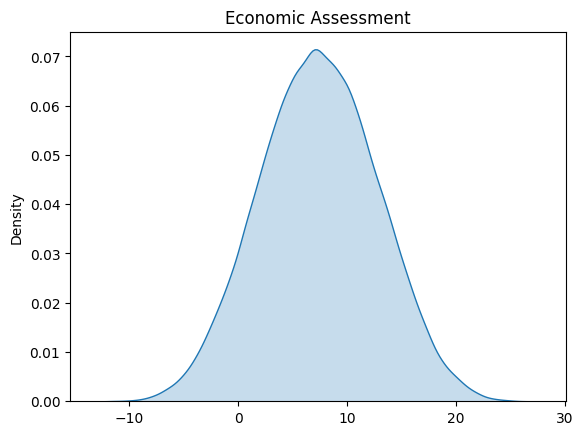

In [ ]:
a = EconomicAssessment(data)
a.assess('gaussian')
a.Graph()

In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame(data)
# The previous line was causing an error because df.apply() received an array of numbers
# instead of a callable function. To generate random numbers based on the mean and std
# of 'inflow' for the length of the DataFrame, you can directly assign the result:
df['dfrand'] = np.random.normal(df['inflow'].mean(), df['inflow'].std(), size=len(df))
df['dfsum']=df['dfrand'].cumsum()
df

,period,inflow,outflow,dfrand,dfsum
0,1,33,18,35.479438,35.479438
1,2,38,26,31.305310,66.784748
2,3,40,29,38.035040,104.819788
